In [ ]:
import pandas as pd
from google.colab import files

# Step 1: Upload the file manually
uploaded = files.upload()

# Step 2: Get the uploaded file name automatically
filename = list(uploaded.keys())[0]

# Step 3: Read the CSV
df = pd.read_csv(filename)

# Step 4: Preview
df.head()


Saving crop_yield_with_agronomic_features infosys.csv to crop_yield_with_agronomic_features infosys.csv


,Rainfall,Temperature,Humidity,Wind Speed,Solar Radiation,Soil pH,Soil Moisture,Organic Matter Content,Nitrogen,Phosphorus,Potassium,Crop Type,Plant Population,Fertilizer Application Rate,Tillage Practice,Sowing Date,Weeding Frequency (per season),Crop Yield
0,143.635030,28.579938,76.013396,3.444378,103.081126,7.054994,44.276401,7.585856,12.399195,73.744427,42.880325,Yam,43654,97.24,Conventional,18-03-2022,2,Medium
1,287.678577,32.081485,74.364150,0.860147,100.231111,5.145792,33.378548,2.989674,10.716451,76.266021,20.429955,Soybean,35795,50.57,No-till,17-06-2022,3,Low
2,232.998485,31.402414,44.787710,1.590484,430.584423,5.713239,12.785345,6.714383,30.193792,5.330760,23.899515,Rice,20860,152.25,Strip-till,11-06-2022,3,Low
3,199.664621,22.308499,86.128620,3.981557,120.505594,6.821482,55.925508,7.142390,81.938885,28.780627,29.873824,Yam,25390,75.07,No-till,03-05-2022,2,Medium
4,89.004660,22.238742,68.423610,2.879086,782.172788,6.187313,59.016457,3.778625,91.427289,67.803352,32.401867,Rice,49802,148.29,No-till,27-06-2022,1,Low


In [ ]:
df['Crop Yield'].value_counts()


,count
Crop Yield,
Low,2415
Medium,1454
High,131


In [ ]:
import pickle
label_map = pickle.load(open("label_map.pkl","rb"))
print(label_map)


{0: '🌾 High Yield', 2: '🌤 Medium Yield', 1: '🌱 Low Yield'}


In [ ]:
df = pd.read_csv("preprocessed_dataset.csv")
print(df["Crop Type"].unique())


[4 3 2 0 1]


In [ ]:
import pandas as pd

df = pd.read_csv("preprocessed_dataset.csv")
print("📋 Columns in dataset:", df.columns.tolist())


📋 Columns in dataset: ['Rainfall', 'Temperature ', 'Humidity ', 'Wind Speed ', 'Solar Radiation', 'Soil pH', 'Soil Moisture ', 'Organic Matter Content ', 'Nitrogen ', 'Phosphorus ', 'Potassium ', 'Crop Type', 'Plant Population ', 'Fertilizer Application Rate ', 'Tillage Practice', 'Sowing Date', 'Weeding Frequency (per season)', 'Crop Yield']


In [ ]:
print(y_train.unique())
print(y_train.value_counts())


[2 1 0]
Crop Yield
1    1932
2    1163
0     105
Name: count, dtype: int64


📂 Please upload your dataset CSV file...


Saving preprocessed_dataset.csv to preprocessed_dataset (4).csv
✅ Loaded dataset: preprocessed_dataset (4).csv

🧾 Cleaned Columns:
['Rainfall', 'Temperature', 'Humidity', 'Wind Speed', 'Solar Radiation', 'Soil pH', 'Soil Moisture', 'Organic Matter Content', 'Nitrogen', 'Phosphorus', 'Potassium', 'Crop Type', 'Plant Population', 'Fertilizer Application Rate', 'Tillage Practice', 'Sowing Date', 'Weeding Frequency (per season)', 'Crop Yield']

🌾 Crop Type Encoding Map:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}

⚖️ Applying SMOTE for class balance...
✅ Class distribution after SMOTE:
 Crop Yield
2    1932
1    1932
0    1932
Name: count, dtype: int64

⚙️ Class Weights Applied: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0), np.int64(2): np.float64(1.0)}

📊 Final Model Accuracy: 0.9463
              precision    recall  f1-score   support

           0       0.68      0.65      0.67        26
           1       0.98      0.95      0.96       483
           2       0.92      0.97      0.94

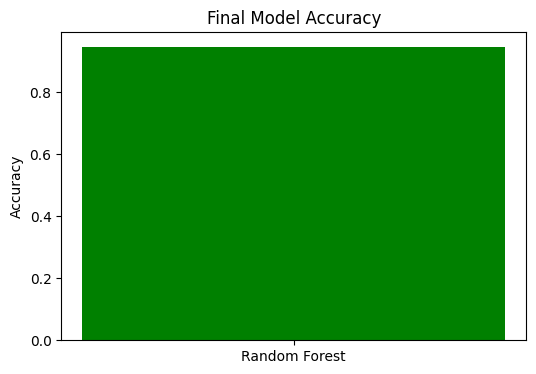

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏁 Model Training Completed Successfully!
✅ Files saved as:
   • crop_yield_model.pkl
   • crop_yield_scaler.pkl
   • crop_yield_label_map.pkl


In [ ]:
# =====================================================
# 🌾 Crop Yield Prediction – Final Balanced Model
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import joblib
from google.colab import files

# --- Step 1: Upload Dataset ---
print("📂 Please upload your dataset CSV file...")
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)
print(f"✅ Loaded dataset: {filename}")

# --- Step 2: Clean Column Names ---
df.columns = df.columns.str.strip().str.replace(r"\s+", " ", regex=True)
print("\n🧾 Cleaned Columns:")
print(df.columns.tolist())

# --- Step 3: Select Required Features ---
required_features = [
    'Rainfall', 'Temperature', 'Humidity', 'Soil pH',
    'Soil Moisture', 'Nitrogen', 'Phosphorus', 'Potassium', 'Crop Type'
]
target_column = 'Crop Yield'

# --- Step 4: Drop Missing Values ---
df = df.dropna(subset=required_features + [target_column])

# --- Step 5: Encode Crop Type ---
df['Crop Type'] = df['Crop Type'].astype('category').cat.codes
print("\n🌾 Crop Type Encoding Map:")
print(dict(enumerate(df['Crop Type'].astype('category').cat.categories)))

# --- Step 6: Split Features and Target ---
X = df[required_features]
y = df[target_column]

# --- Step 7: Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- Step 8: Apply SMOTE for Class Balance ---
print("\n⚖️ Applying SMOTE for class balance...")
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("✅ Class distribution after SMOTE:\n", pd.Series(y_train_res).value_counts())

# --- Step 9: Apply Class Weights ---
classes = np.unique(y_train_res)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_res)
class_weights_dict = dict(zip(classes, class_weights))
print("\n⚙️ Class Weights Applied:", class_weights_dict)

# --- Step 10: Standardize Data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# --- Step 11: Train Random Forest Model ---
model = RandomForestClassifier(random_state=42, class_weight=class_weights_dict)
model.fit(X_train_scaled, y_train_res)

# --- Step 12: Evaluate Model ---
preds = model.predict(X_test_scaled)
acc = accuracy_score(y_test, preds)
print(f"\n📊 Final Model Accuracy: {acc:.4f}")
print(classification_report(y_test, preds))

# --- Step 13: Plot Accuracy Distribution ---
plt.figure(figsize=(6, 4))
plt.bar(["Random Forest"], [acc], color="green")
plt.title("Final Model Accuracy")
plt.ylabel("Accuracy")
plt.show()

# --- Step 14: Save Model, Scaler, and Label Map ---
label_map = {0: "🌾 High Yield", 1: "🌱 Low Yield", 2: "🌤 Medium Yield"}

# ✅ NEW FILE NAMES
joblib.dump(model, "crop_yield_model.pkl")
joblib.dump(scaler, "crop_yield_scaler.pkl")
joblib.dump(label_map, "crop_yield_label_map.pkl")

# --- Step 15: Download Files ---
files.download("crop_yield_model.pkl")
files.download("crop_yield_scaler.pkl")
files.download("crop_yield_label_map.pkl")

print("\n🏁 Model Training Completed Successfully!")
print("✅ Files saved as:")
print("   • crop_yield_model.pkl")
print("   • crop_yield_scaler.pkl")
print("   • crop_yield_label_map.pkl")


In [ ]:
import joblib
scaler = joblib.load("crop_yield_scaler.pkl")
print(scaler.feature_names_in_)


['Rainfall' 'Temperature' 'Humidity' 'Soil pH' 'Soil Moisture' 'Nitrogen'
 'Phosphorus' 'Potassium' 'Crop Type']


In [ ]:
label_map = joblib.load("crop_yield_label_map.pkl")
print(label_map)


{0: '🌾 High Yield', 1: '🌱 Low Yield', 2: '🌤 Medium Yield'}


In [ ]:
# Step 1: Reload the dataset (original CSV)
print("📂 Please upload your dataset CSV file...")
uploaded = files.upload()
# Step 2: Convert to category (temporarily, just for mapping)
df['Crop Type'] = df['Crop Type'].astype('category')

# Step 3: Print the mapping of codes ↔ crop names
mapping = dict(enumerate(df['Crop Type'].cat.categories))
print("Crop Type Encoding Map:")
print(mapping)


📂 Please upload your dataset CSV file...


Saving crop_yield_with_agronomic_features infosys.csv to crop_yield_with_agronomic_features infosys (1).csv
Crop Type Encoding Map:
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


In [ ]:
print(df["Crop Type"].unique())
print(df["Crop Type"].head(10))


[4, 3, 2, 0, 1]
Categories (5, int8): [0, 1, 2, 3, 4]
0    4
1    3
2    2
3    4
4    2
5    0
6    2
7    2
8    1
9    4
Name: Crop Type, dtype: category
Categories (5, int8): [0, 1, 2, 3, 4]


In [ ]:
# --- Step 7A: Save the crop type mapping before encoding ---
X['Crop Type'] = X['Crop Type'].astype('category')
crop_type_map = dict(enumerate(X['Crop Type'].cat.categories))
print("✅ Crop Type Encoding Map:", crop_type_map)

# --- Step 7B: Apply encoding ---
X['Crop Type'] = X['Crop Type'].cat.codes

# --- Save this mapping for Streamlit use ---
import joblib
joblib.dump(crop_type_map, "crop_type_map.pkl")


✅ Crop Type Encoding Map: {0: 0, 1: 1, 2: 2, 3: 3, 4: 4}


/tmp/ipython-input-1239694157.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Crop Type'] = X['Crop Type'].astype('category')
/tmp/ipython-input-1239694157.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Crop Type'] = X['Crop Type'].cat.codes


['crop_type_map.pkl']

In [ ]:
# =====================================================
# 🌾 Step 1: Upload Original Dataset
# =====================================================
import pandas as pd
from google.colab import files
import joblib

print("📂 Please upload your ORIGINAL dataset CSV file (with crop names)...")
uploaded = files.upload()

# Get uploaded filename
filename = list(uploaded.keys())[0]
raw_df = pd.read_csv(filename)
print(f"✅ Loaded: {filename}")
print("Columns found:", raw_df.columns.tolist())

# =====================================================
# 🌱 Step 2: Extract Crop Type Mapping
# =====================================================
if "Crop Type" not in raw_df.columns:
    raise ValueError("❌ 'Crop Type' column not found in dataset! Check the file again.")

# Get sorted unique crop names
unique_crops = sorted(raw_df["Crop Type"].unique())

# Create mapping {0: 'Cassava', 1: 'Maize', ...}
crop_type_map = {i: crop for i, crop in enumerate(unique_crops)}
print("\n✅ Actual Crop Type Map:")
for k, v in crop_type_map.items():
    print(f"{k}: {v}")

# =====================================================
# 💾 Step 3: Save Crop Type Map for Streamlit
# =====================================================
joblib.dump(crop_type_map, "crop_type_map.pkl")
files.download("crop_type_map.pkl")

print("\n🎉 crop_type_map.pkl saved and ready for Streamlit use!")


📂 Please upload your ORIGINAL dataset CSV file (with crop names)...


Saving crop_yield_with_agronomic_features infosys.csv to crop_yield_with_agronomic_features infosys (2).csv
✅ Loaded: crop_yield_with_agronomic_features infosys (2).csv
Columns found: ['Rainfall ', 'Temperature ', 'Humidity ', 'Wind Speed ', 'Solar Radiation', 'Soil pH', 'Soil Moisture ', 'Organic Matter Content ', 'Nitrogen ', 'Phosphorus ', 'Potassium ', 'Crop Type', 'Plant Population ', 'Fertilizer Application Rate ', 'Tillage Practice', 'Sowing Date', 'Weeding Frequency (per season)', 'Crop Yield']

✅ Actual Crop Type Map:
0: Cassava
1: Maize
2: Rice
3: Soybean
4: Yam


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 crop_type_map.pkl saved and ready for Streamlit use!


In [ ]:
from google.colab import files
import pandas as pd

uploaded = files.upload()  # prompts to upload your CSV file
filename = list(uploaded.keys())[0]

df_original = pd.read_csv(filename)
df_original.columns = df_original.columns.str.strip().str.replace(r"\s+", " ", regex=True)

df_original['Crop Yield'] = df_original['Crop Yield'].astype('category')
y = df_original['Crop Yield'].cat.codes
label_map = dict(enumerate(df_original['Crop Yield'].cat.categories))

print("✅ Dataset loaded successfully!")
print("Label Map:", label_map)


Saving your_dataset.csv to your_dataset.csv
✅ Dataset loaded successfully!
Label Map: {0: 'High', 1: 'Low', 2: 'Medium'}
